In [2]:
%reload_ext autoreload
%autoreload 2
import os
import polars as pl
import numpy as np
from behave_analysis.visualize.visualize_utils import open_tracking_data
from behave_analysis.analyze.analyze_homing_signature import PhaseOneAnalyzer
from behave_analysis.process.process import Process

import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_shelt_17aug, JAL3_mush_21aug, JAL3_flip1_22aug, JAL3_flip2_25aug, JAL3_flip3_29aug, JAL3_flip4_1sept, JAL3_flip5_4sept, JAL3_flip6_7sept

from behave_analysis.database.Experiments.JAL004_ex import JAL4_shelt_17aug, JAL4_mush_18aug, JAL4_flip1_21Aug, JAL4_mush2_22Aug, JAL4_flip3_28aug, JAL4_flip4_3Sept, JAL4_flip5_11Sept, JAL4_flip6_19Sept

from behave_analysis.database.Experiments.JAL005_ex import JAL5_shelt_2Sept, JAL5_barr_5Sept, JAL5_flip1_8Sept, JAL5_flip3_21Sept, JAL5_mush_3oct

from behave_analysis.database.Experiments.JAL006_ex import JAL6_hab_1mar, JAL6_shelt_4mar, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip6_28mar, JAL6_flip7_1apr, JAL6_flip8_5apr


from behave_analysis.database.Experiments.JAL007_ex import JAL7_hab_1mar, JAL7_empty_shelter_5mar, JAL7_flip2_12mar, JAL7_flip3_15mar, JAL7_flip4_19mar, JAL7_flip5_22mar, JAL7_flip7_4apr, JAL7_flip8_9apr, JAL7_flip9_16apr, JAL7_flip10_23apr, JAL7_tiny_30apr

from behave_analysis.database.Experiments.JAL008_ex import (
    JAL8_shelt_22apr,
    JAL8_flip1_25apr,
    JAL8_flip2_29apr,
    JAL8_tiny_3may,
    JAL8_flip3_7may,
    JAL8_flip4_10may,
    JAL8_flip5_14may,
    JAL8_tiny2_21may,
)

experiments_objects = {"JAL4_3rdSept": JAL4_flip4_3Sept,
        "JAL4_19thSept": JAL4_flip6_19Sept,
        "JAL4_28aug": JAL4_flip3_28aug,
        "JAL4_11thSept": JAL4_flip5_11Sept,
        "JAL5_8thSept": JAL5_flip1_8Sept,
        "JAL5_21stSept": JAL5_flip3_21Sept,
        "JAL6_28mar": JAL6_flip6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_flip8_9apr, # almost no homings
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_flip9_16apr, 
        "JAL7_23apr": JAL7_flip10_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_flip5_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}


In [3]:
e = 19 # choose a session

cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
session_name = list(experiments_objects.keys())[e]
exp = experiments_objects[session_name]
session = Process(exp).load_session()
tracking_data = open_tracking_data(session)
video_df_path = os.path.join(session['base_path'], session['processed_path'], 'full_video_dataframe.csv')
video_df = pl.read_csv(video_df_path)

2026-06-11 09:15:32.771 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [38]:
# Initialize analyzer with your experiments list
analyzer = PhaseOneAnalyzer(experiments_objects)

# Step 1: Load all session data
analyzer.load_all_sessions()

2026-06-12 18:38:07.431 | INFO     | behave_analysis.analyze.analyze_homing_signature:load_all_sessions:87 - Loading 20 sessions...
2026-06-12 18:38:07.434 | INFO     | behave_analysis.analyze.analyze_homing_signature:load_all_sessions:89 - Loading session: JAL4_3rdSept
2026-06-12 18:38:07.583 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-06-12 18:38:38.377 | INFO     | behave_analysis.analyze.analyze_homing_signature:load_all_sessions:102 - Escape object found. Loading...
2026-06-12 18:38:38.412 | SUCCESS  | behave_analysis.analyze.analyze_homing_signature:load_all_sessions:124 -   Loaded JAL4_3rdSept
2026-06-12 18:38:38.414 | INFO     | behave_analysis.analyze.analyze_homing_signature:load_all_sessions:89 - Loading session: JAL4_19thSept
2026-06-12 18:38:38.565 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load

In [79]:
# Cell: Create frame labels and define runs
analyzer.create_frame_labels()

# Extract runs with empirically tuned threshold
analyzer.extract_runs(speed_threshold=4.0, gap_tolerance_frames=1)

# Validate hypothesis: homings+escapes within runs
hypothesis_check = analyzer.validate_run_hypothesis()
print("\n✓ Run Hypothesis Validation:")
for session_name, result in hypothesis_check.items():
    print(f"  {session_name}: {result['pct_target_in_runs']:.1f}% target in runs")

2026-06-17 12:56:40.958 | INFO     | behave_analysis.analyze.analyze_homing_signature:create_frame_labels:144 - Creating frame-level labels...
2026-06-17 12:56:40.972 | INFO     | behave_analysis.analyze.analyze_homing_signature:create_frame_labels:167 -   JAL4_3rdSept: 13315 target frames, 498111 exploration frames
2026-06-17 12:56:40.981 | INFO     | behave_analysis.analyze.analyze_homing_signature:create_frame_labels:167 -   JAL4_19thSept: 13950 target frames, 559072 exploration frames
2026-06-17 12:56:40.994 | INFO     | behave_analysis.analyze.analyze_homing_signature:create_frame_labels:167 -   JAL4_11thSept: 8065 target frames, 449478 exploration frames
2026-06-17 12:56:41.002 | INFO     | behave_analysis.analyze.analyze_homing_signature:create_frame_labels:167 -   JAL5_8thSept: 14365 target frames, 340348 exploration frames
2026-06-17 12:56:41.014 | INFO     | behave_analysis.analyze.analyze_homing_signature:create_frame_labels:167 -   JAL5_21stSept: 8848 target frames, 332707 


✓ Run Hypothesis Validation:
  JAL4_3rdSept: 86.3% target in runs
  JAL4_19thSept: 86.7% target in runs
  JAL4_11thSept: 84.5% target in runs
  JAL5_8thSept: 86.9% target in runs
  JAL5_21stSept: 88.9% target in runs
  JAL6_28mar: 90.2% target in runs
  JAL6_flip4_21mar: 91.6% target in runs
  JAL6_flip3_18mar: 91.5% target in runs
  JAL6_flip5_25mar: 84.4% target in runs
  JAL7_sesh8_9apr: 93.1% target in runs
  JAL7_flip5_22mar: 90.3% target in runs
  JAL7_flip2_12mar: 90.8% target in runs
  JAL7_sesh9_16apr: 91.6% target in runs
  JAL7_23apr: 93.6% target in runs
  JAL8_flip1_25apr: 90.9% target in runs
  JAL8_flip2_29apr: 91.4% target in runs
  JAL8_flip3_7may: 91.7% target in runs
  JAL8_flip4_10may: 86.3% target in runs


In [80]:
# Cell: Extract per-run features
all_run_features = analyzer.extract_features_for_all_runs()
print(f"\n✓ Extracted {len(all_run_features)} total runs")

2026-06-17 12:56:46.791 | INFO     | behave_analysis.analyze.analyze_homing_signature:extract_features_for_all_runs:270 - Extracting per-run features...
c:\users\jasmine\documents\github\jal2_subgoal_pipeline\behave_analysis\analyze\analyze_homing_signature.py:363: RuntimeWarning: Mean of empty slice
  net_dy=net_dy,
2026-06-17 12:57:20.694 | INFO     | behave_analysis.analyze.analyze_homing_signature:extract_features_for_all_runs:299 - Extracted features for 83603 runs



✓ Extracted 83603 total runs


2026-06-17 12:57:58.632 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:401 - Computing feature distributions and discrimination power...
2026-06-17 12:57:58.685 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:406 -   Target runs: 2370
2026-06-17 12:57:58.687 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:407 -   Exploration runs: 81233
2026-06-17 12:57:59.396 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:473 - Top 10 discriminative features:
2026-06-17 12:57:59.398 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:475 -   1. net_dy: Cohen's d=1.895, AUC=0.930
2026-06-17 12:57:59.400 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:475 -   2. net_distance: Cohen's d=1.750, AUC=0.869
2026-06-17 12:57:59.402 | INFO     | behave_

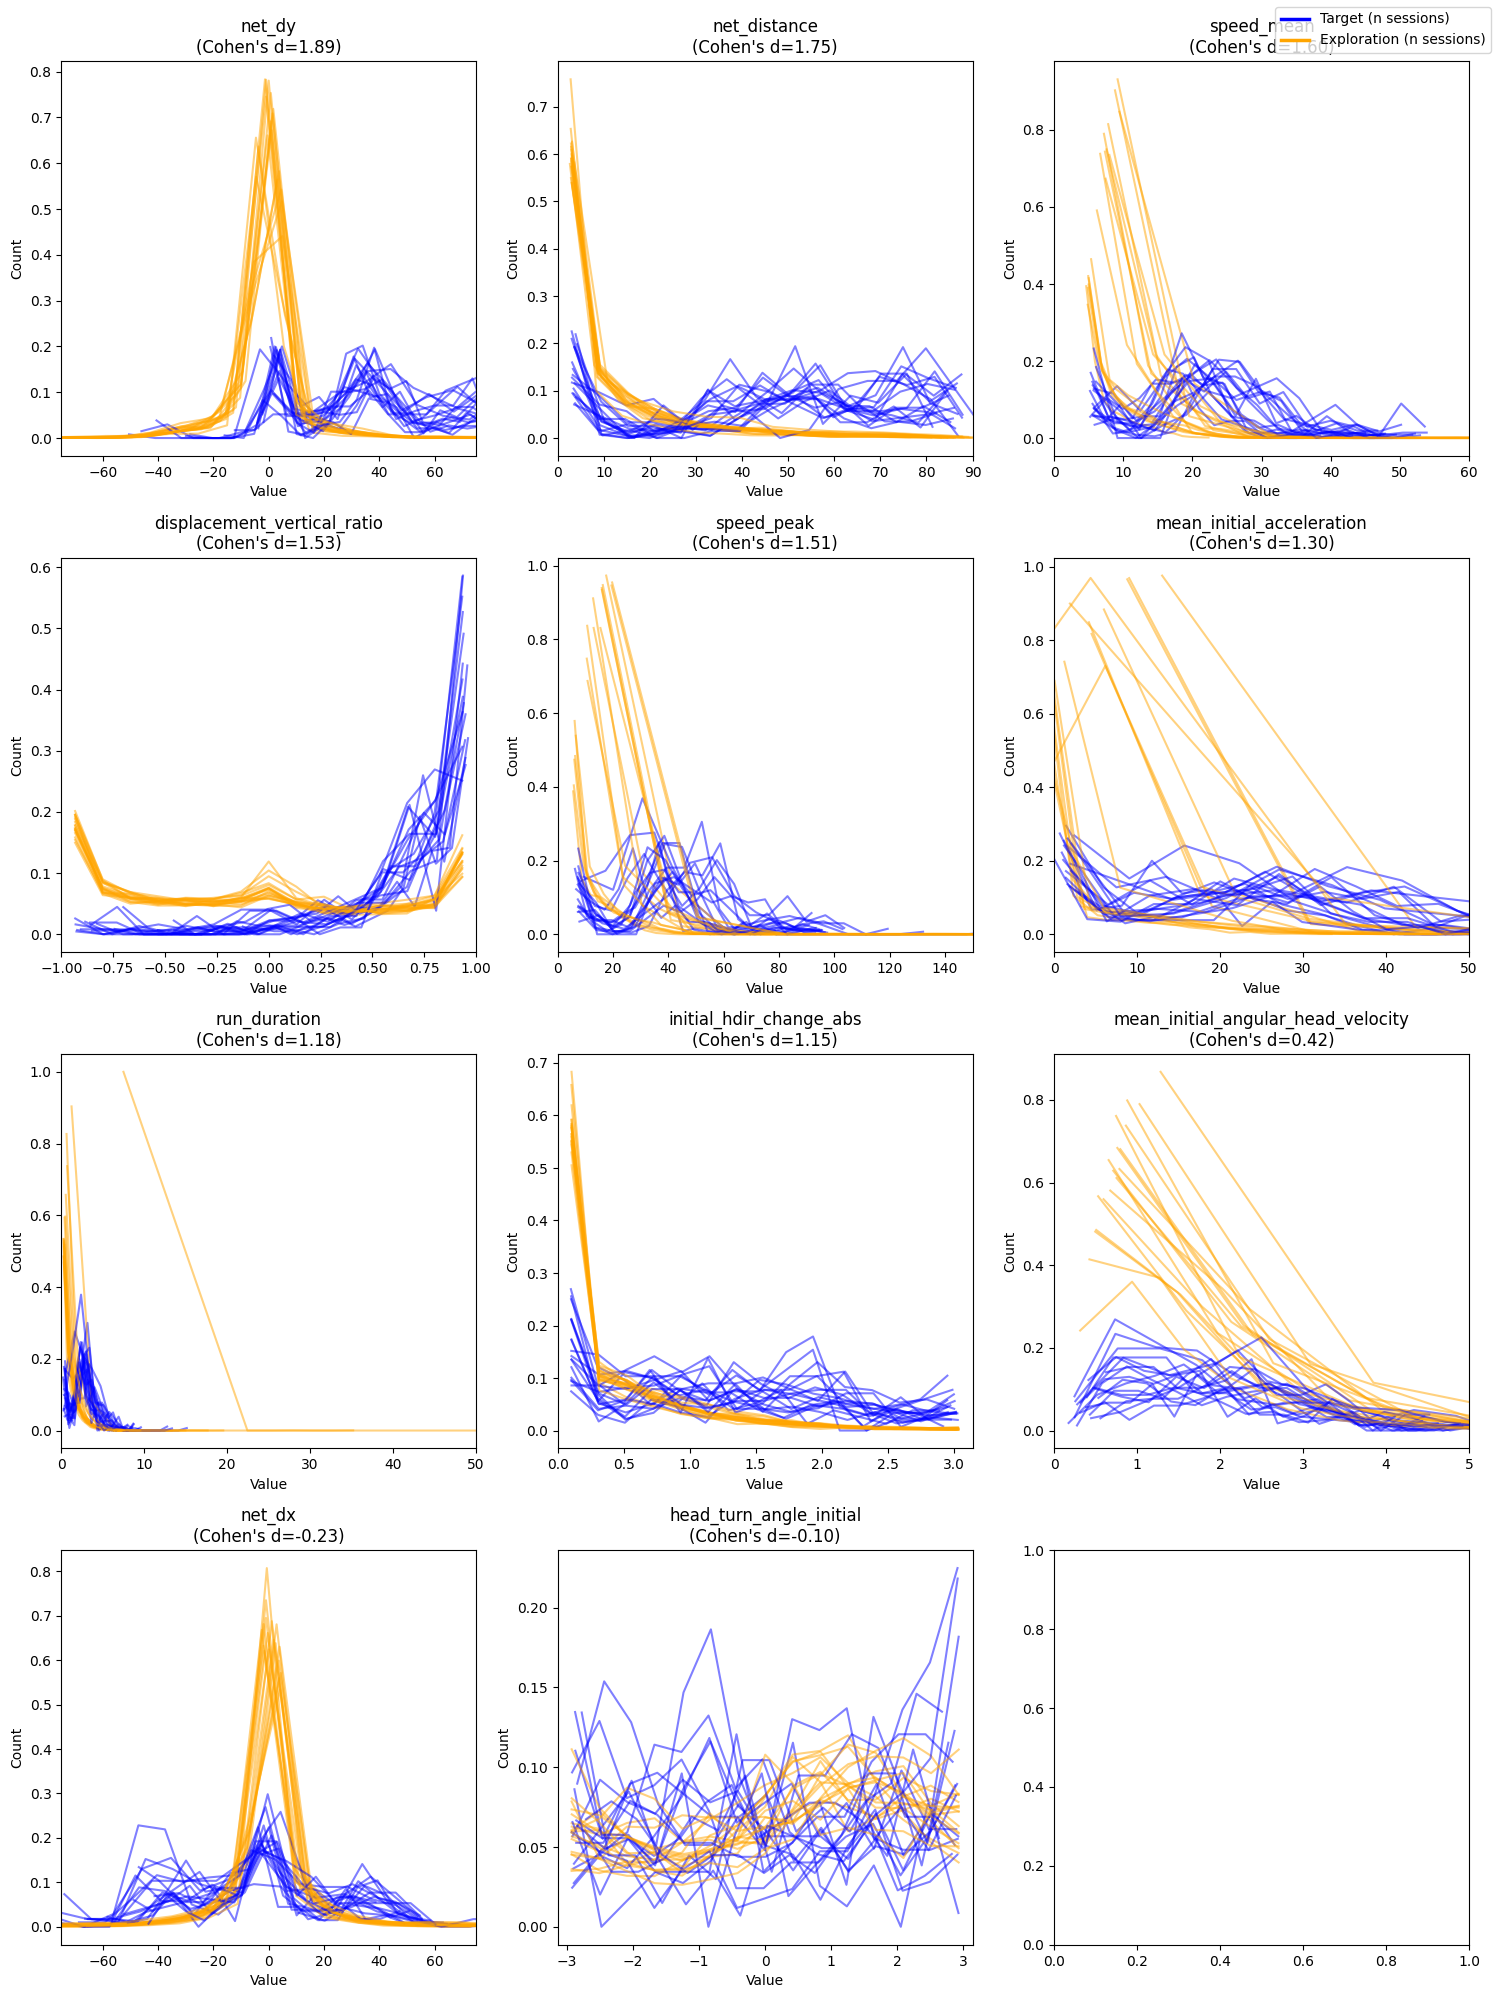

In [81]:
# Cell: Analyze feature distributions
discrimination_results = analyzer.compute_feature_distributions()
analyzer.plot_feature_distributions(only_top_n=len(analyzer.feature_ranking))
plt.show()

# thresholds for features based on this plot
# net_distance_threshold = 10.0 # could be more aggressive
# net_dy = 0
# speed_mean = 5 # could be 10
# speed_peak = 20
# displacement_vertical_ratio = 0 # could be not used to avoid missing runs along barrier
# head_angular_velocity_mean = .02

2026-06-12 14:04:59.478 | INFO     | behave_analysis.analyze.analyze_homing_signature:plot_run_aligned_dynamics_per_session:663 - Plotting onset-aligned dynamics (feature subplots in one figure per session)...


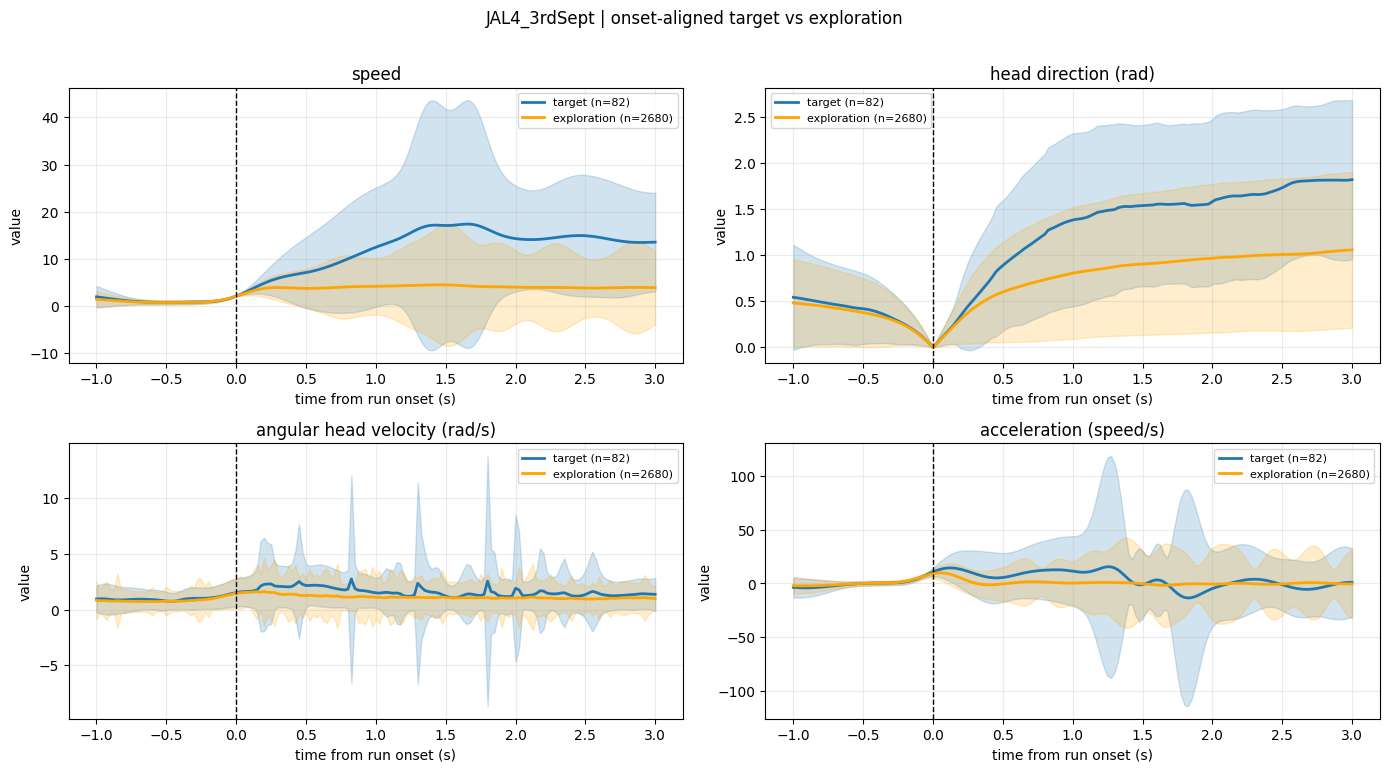

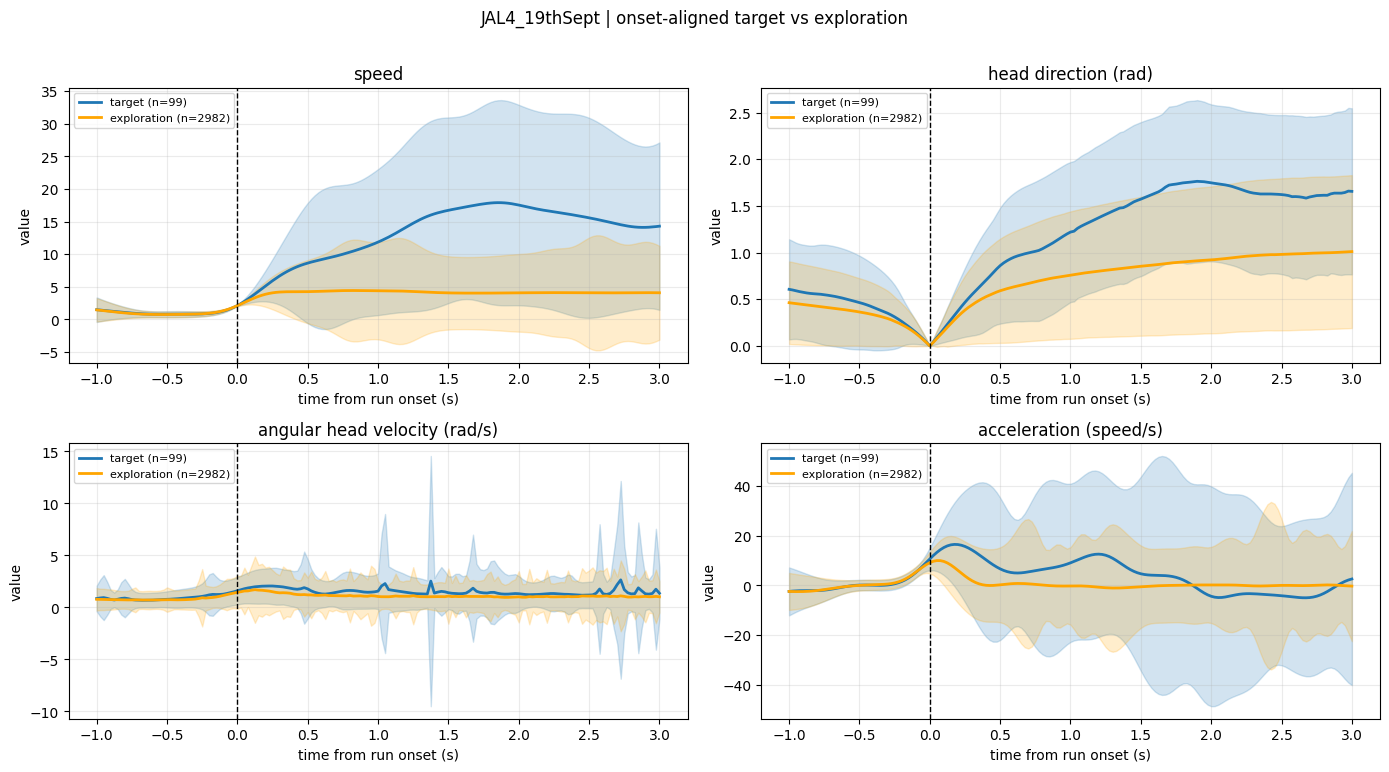

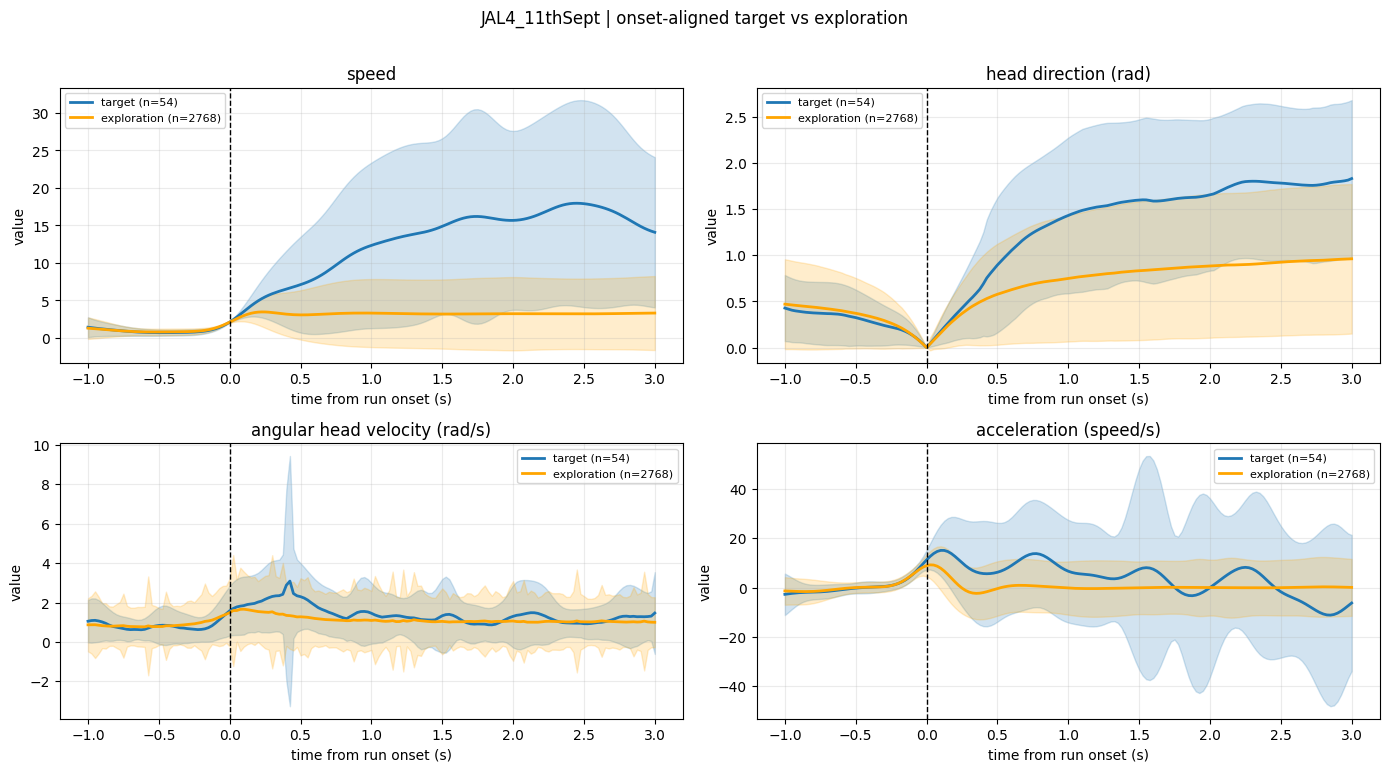

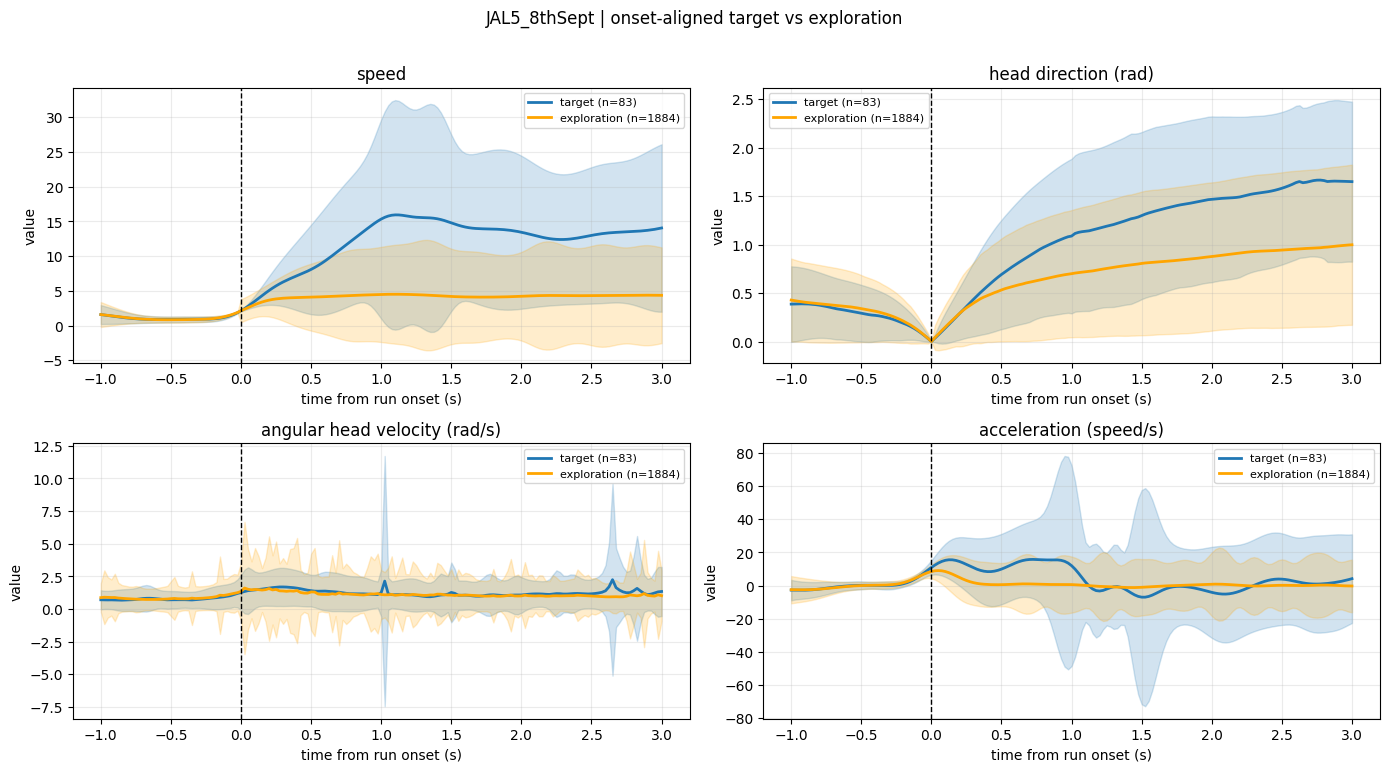

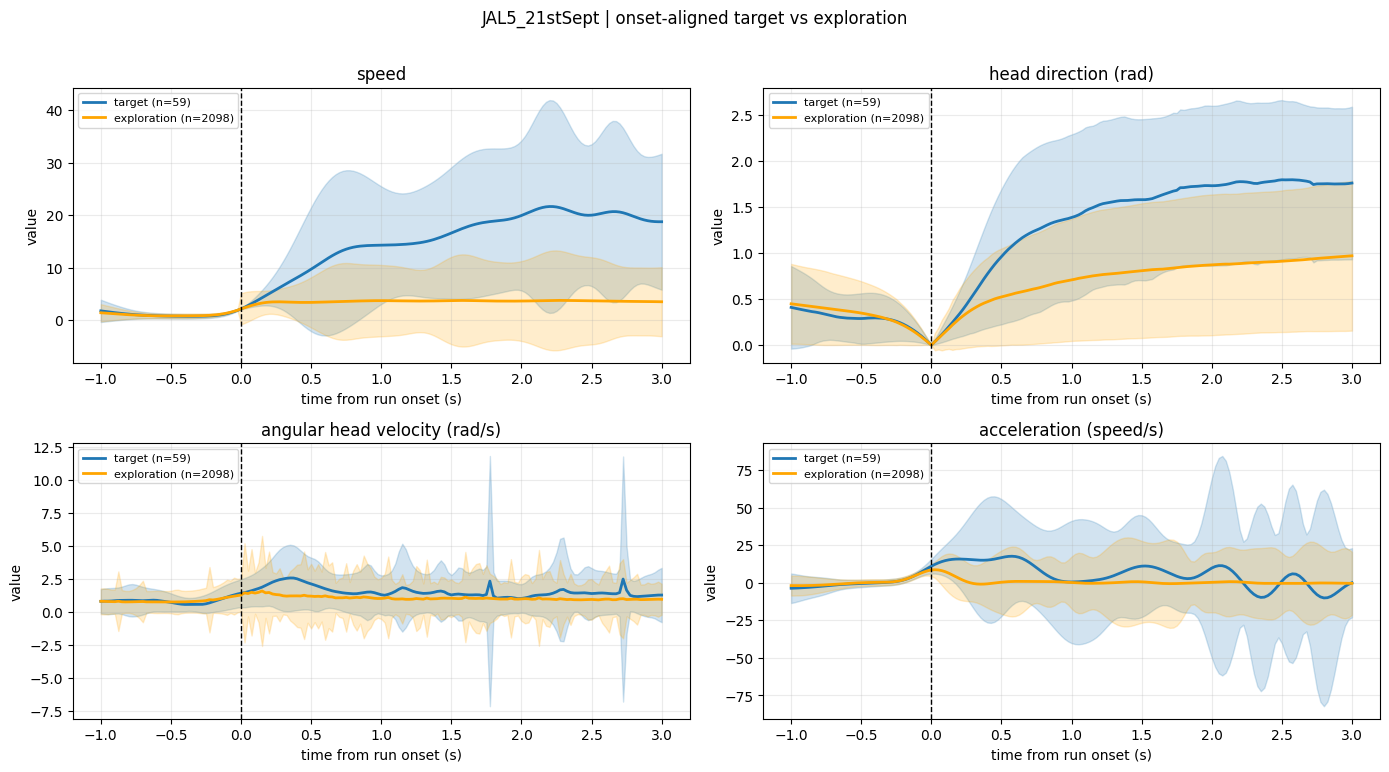

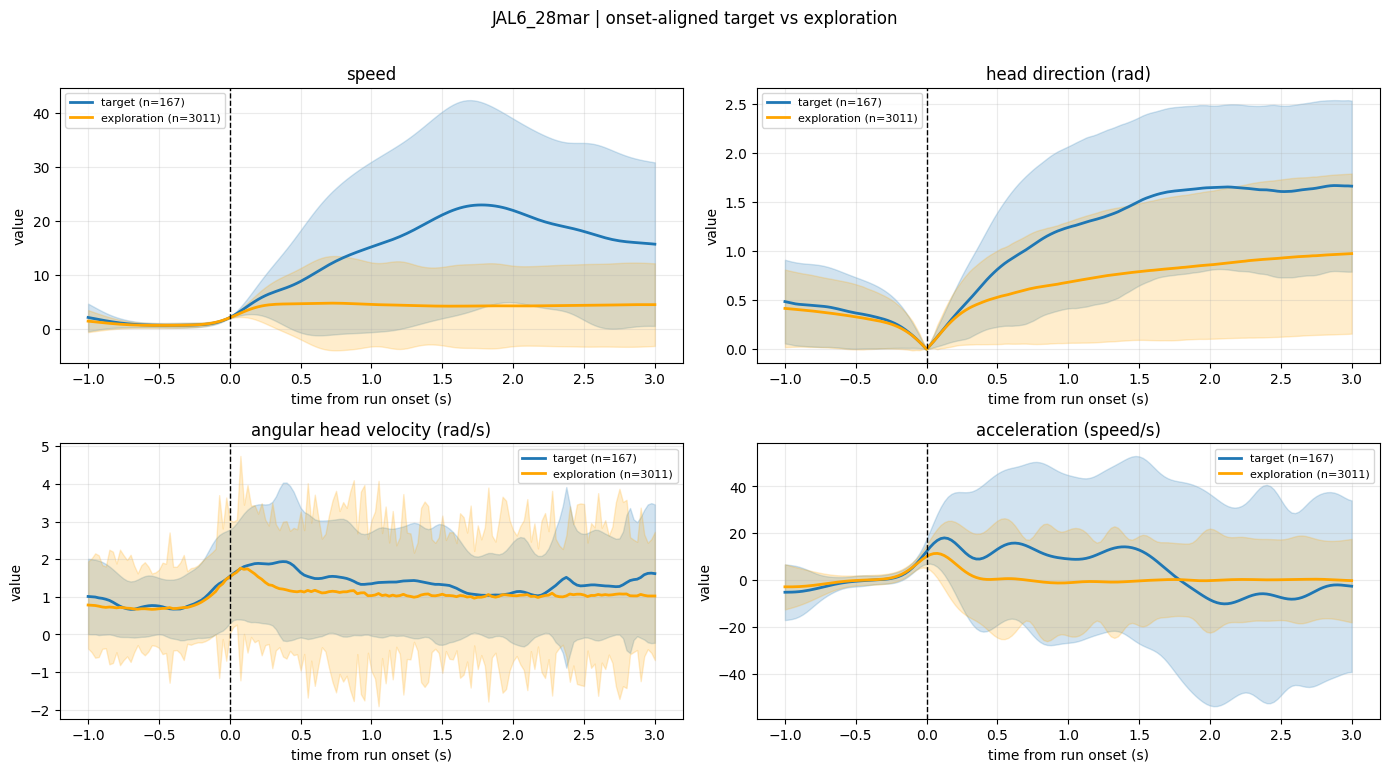

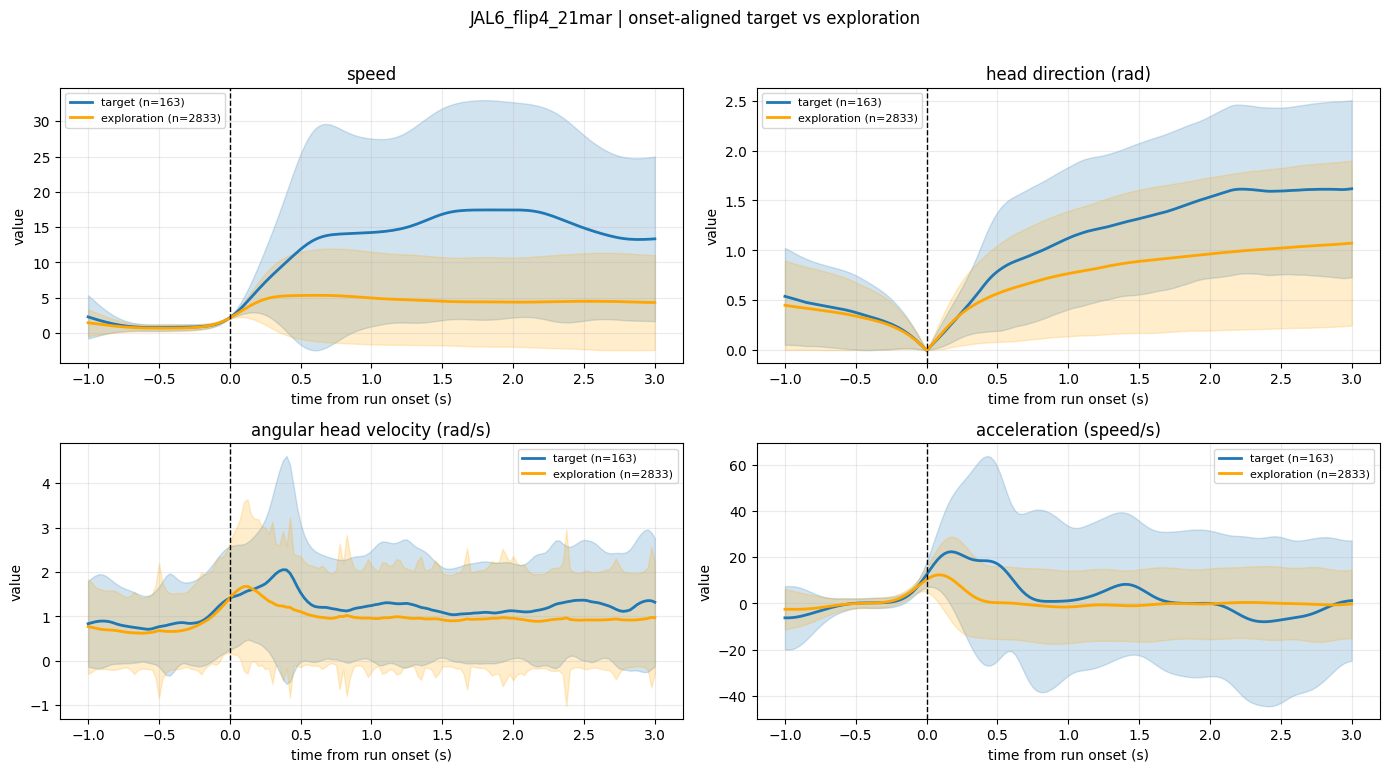

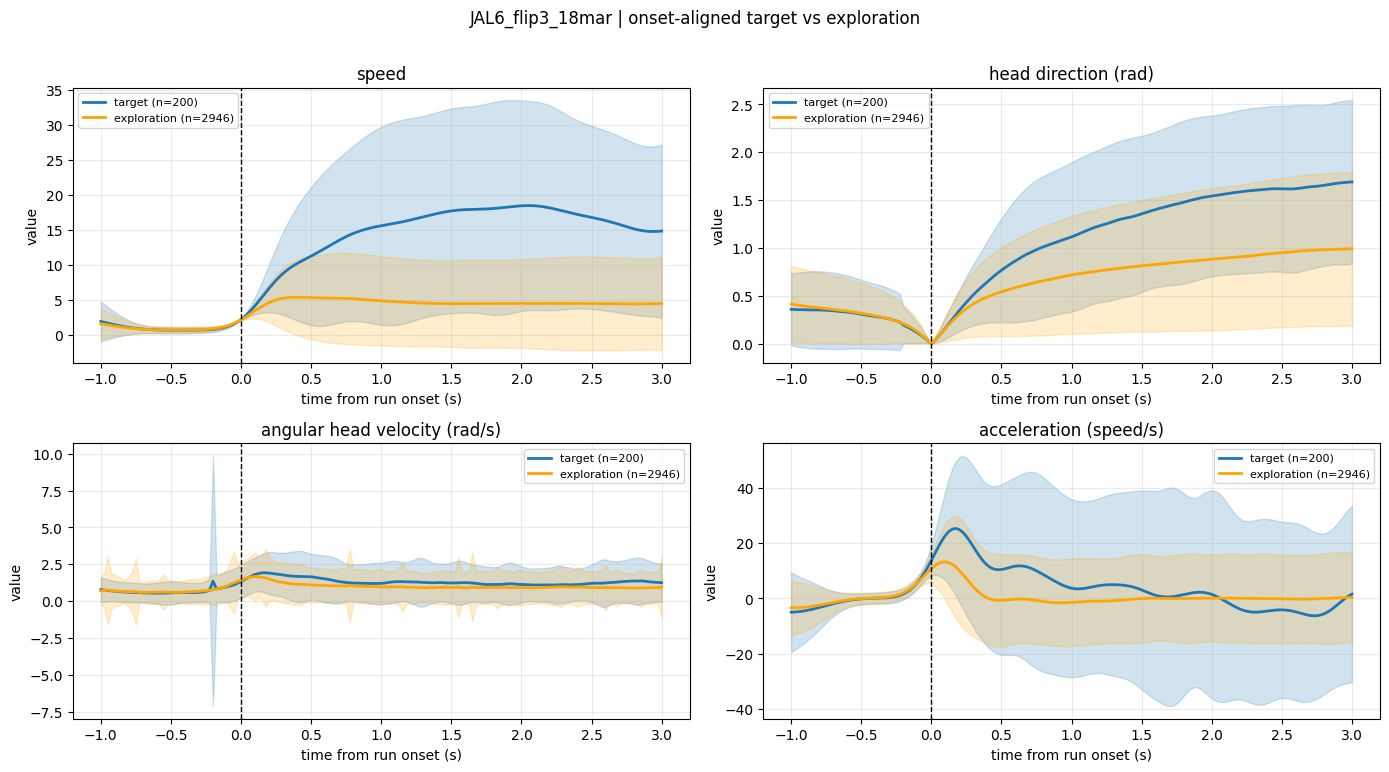

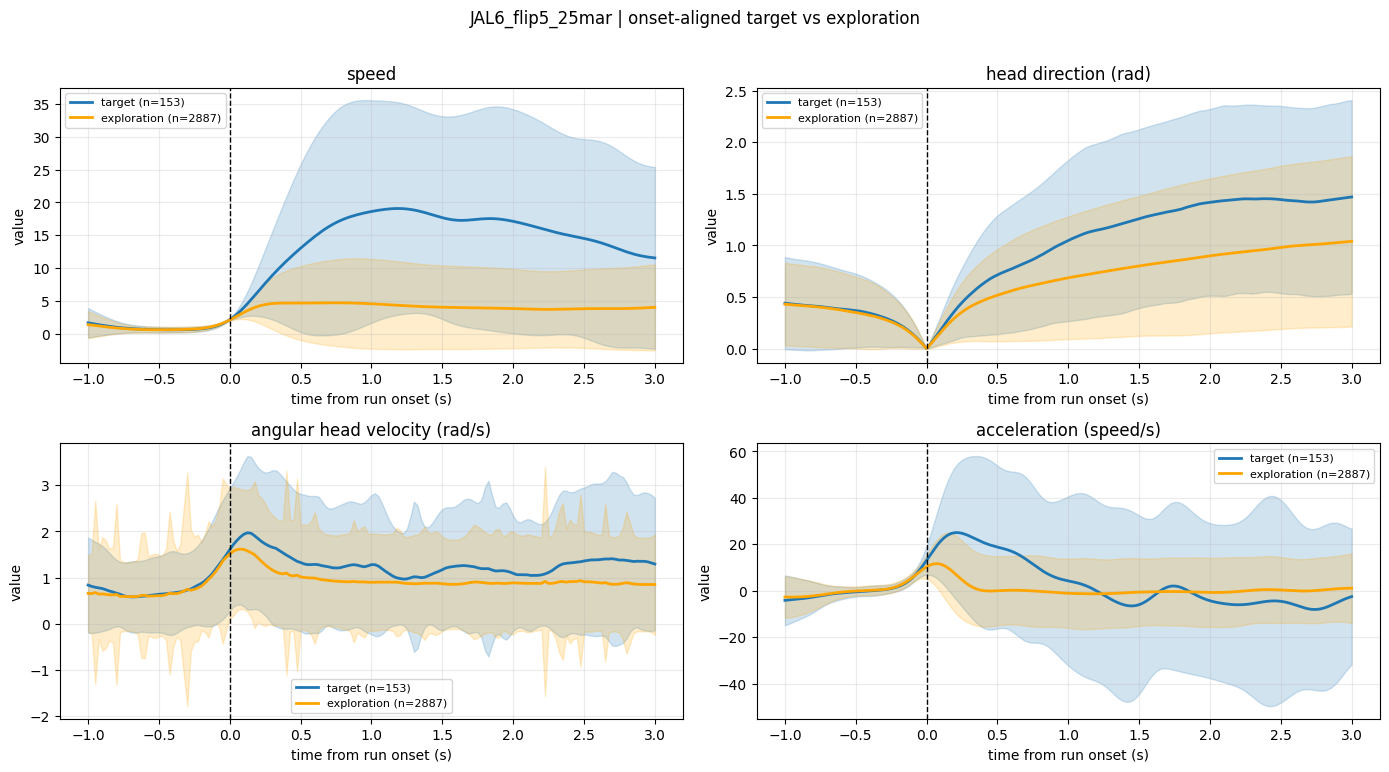

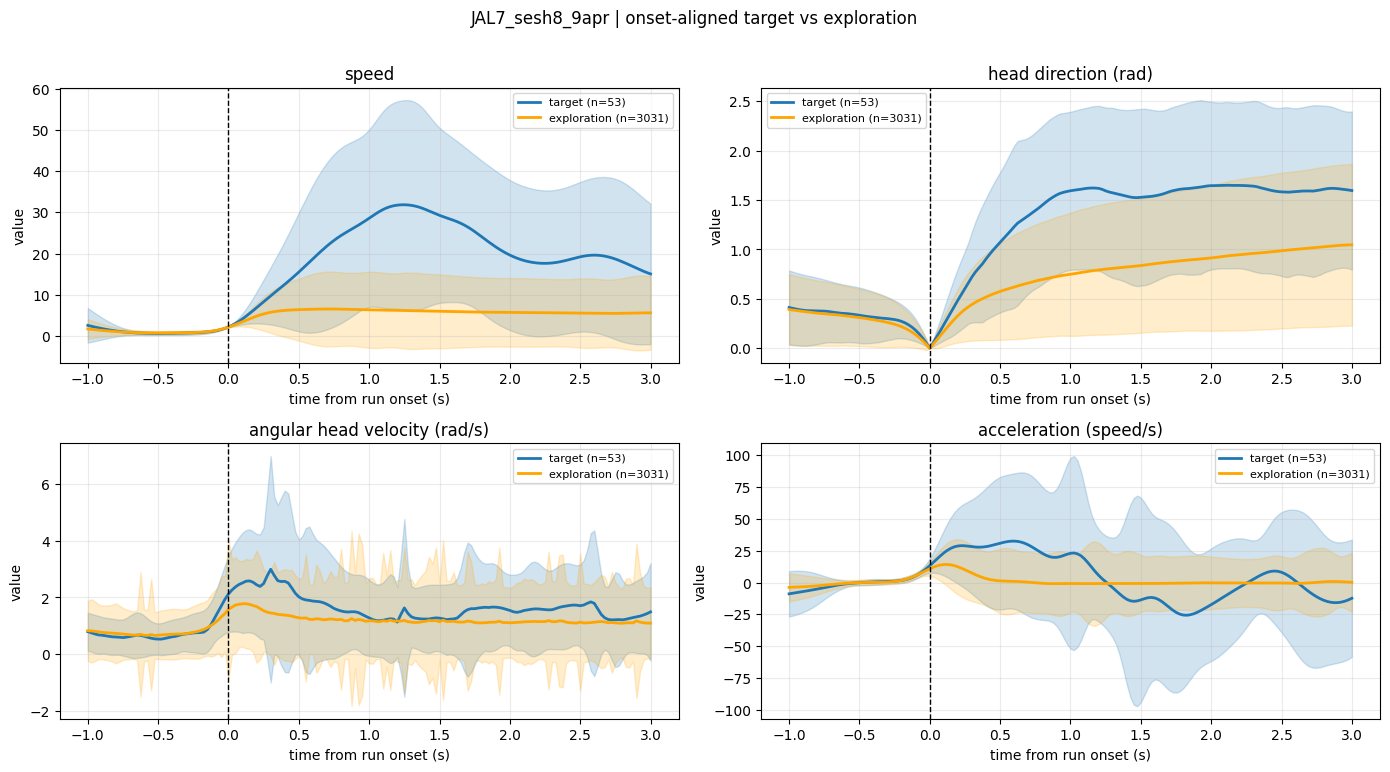

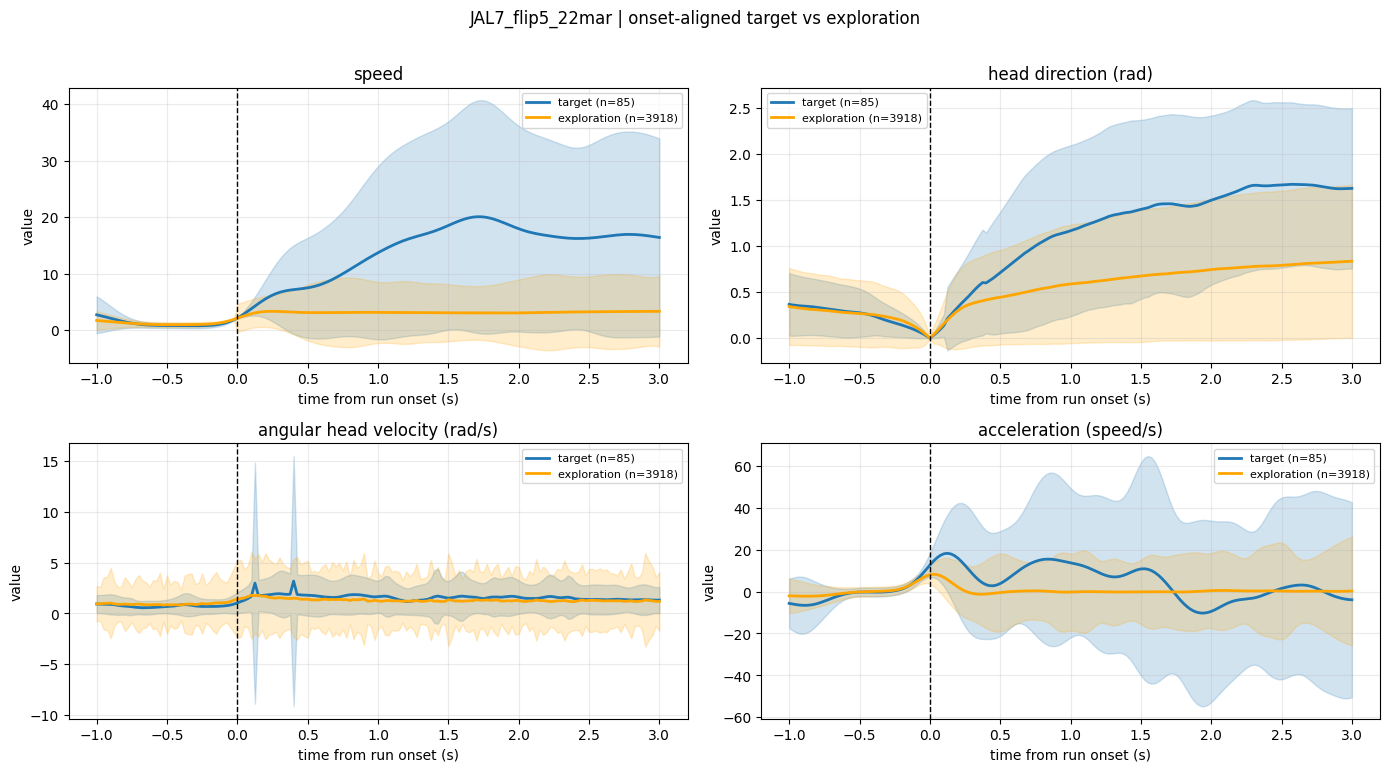

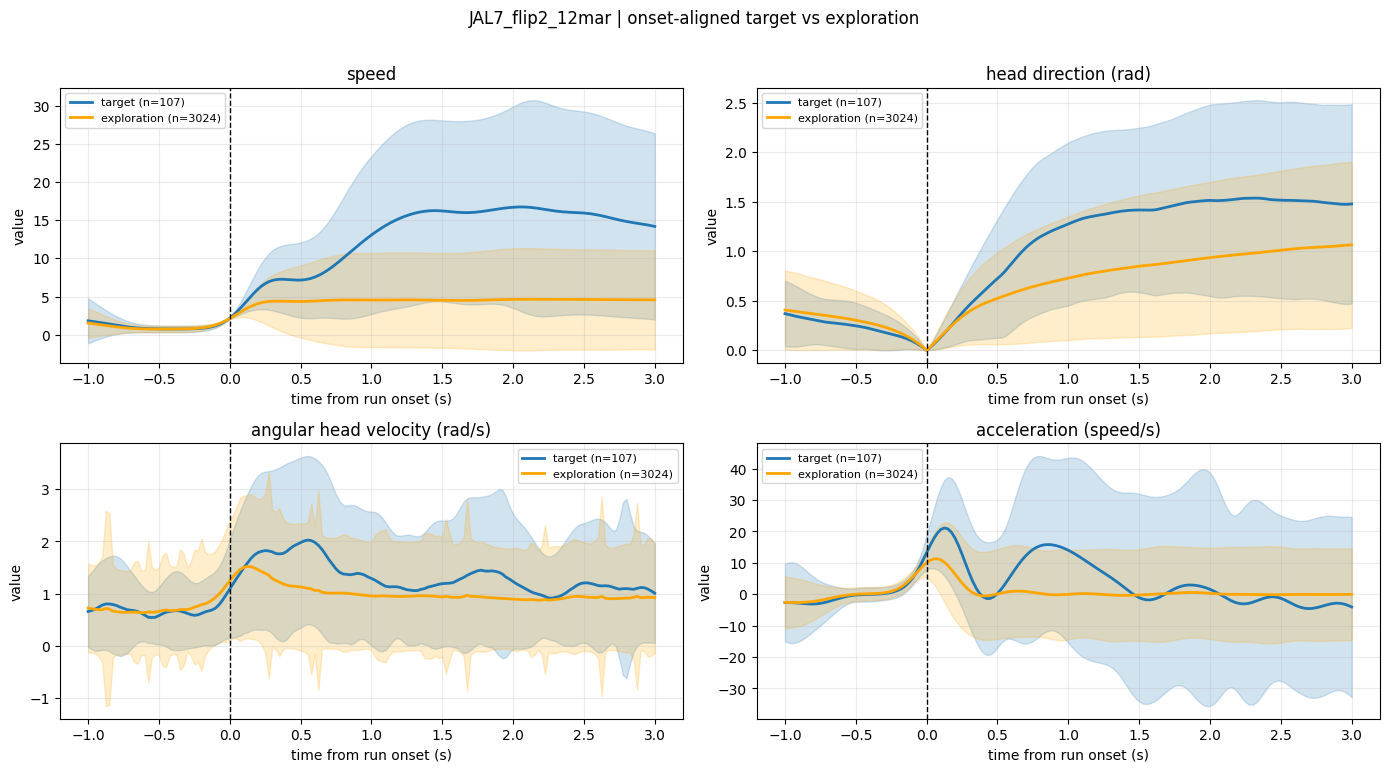

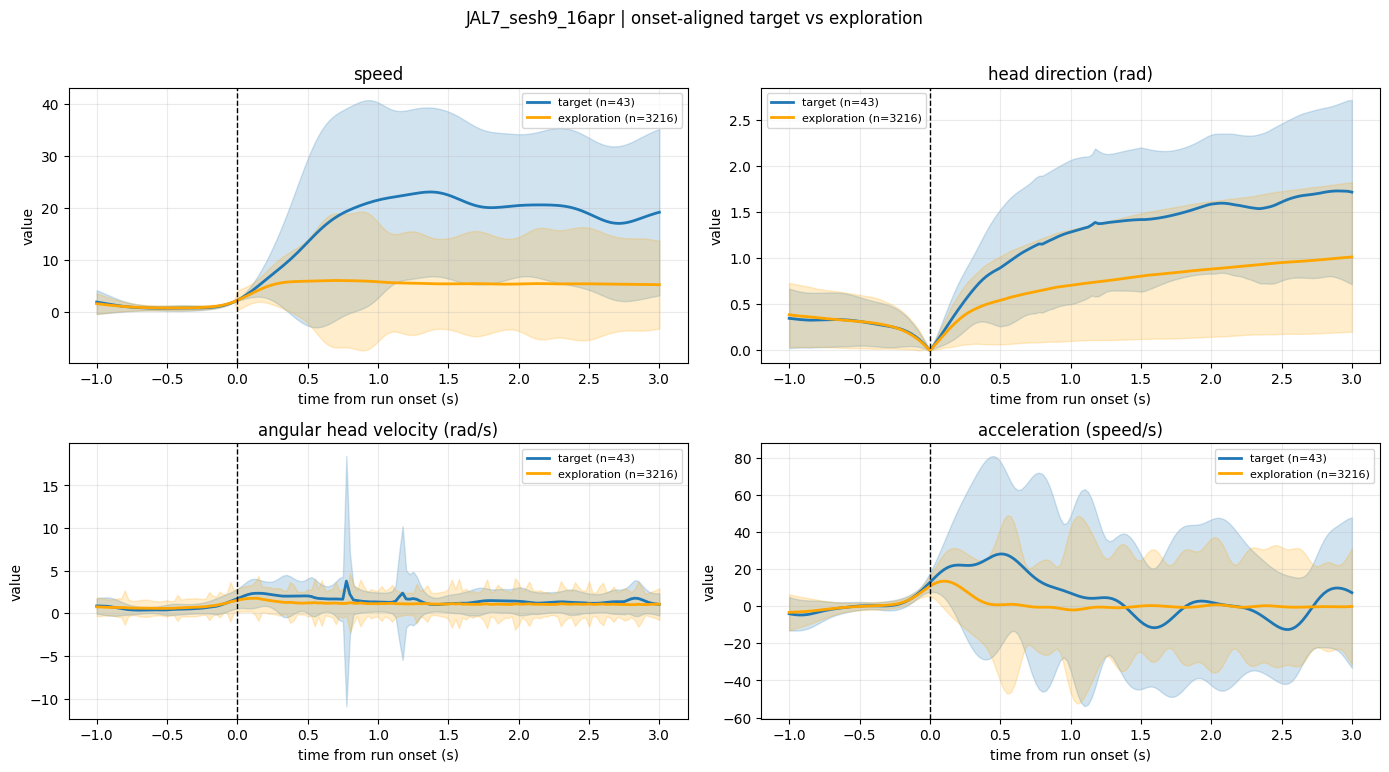

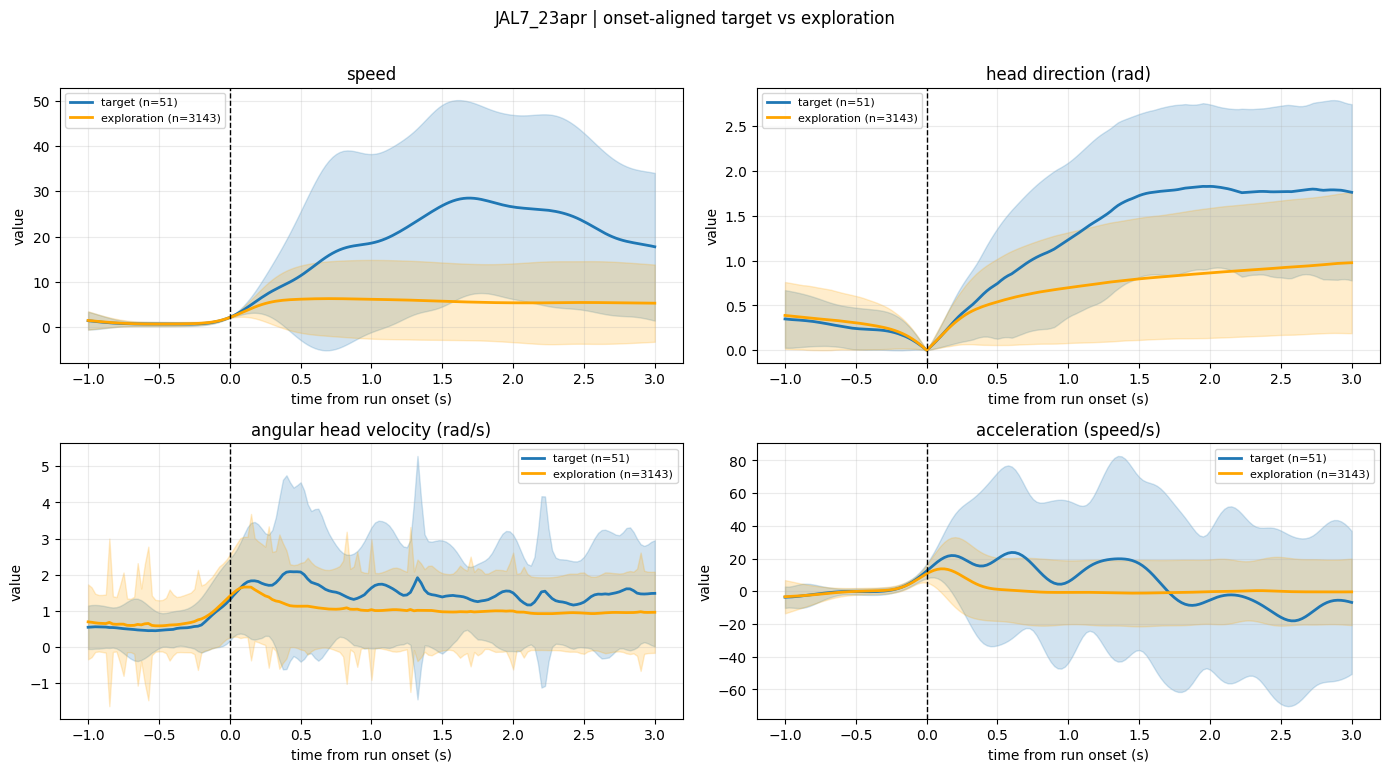

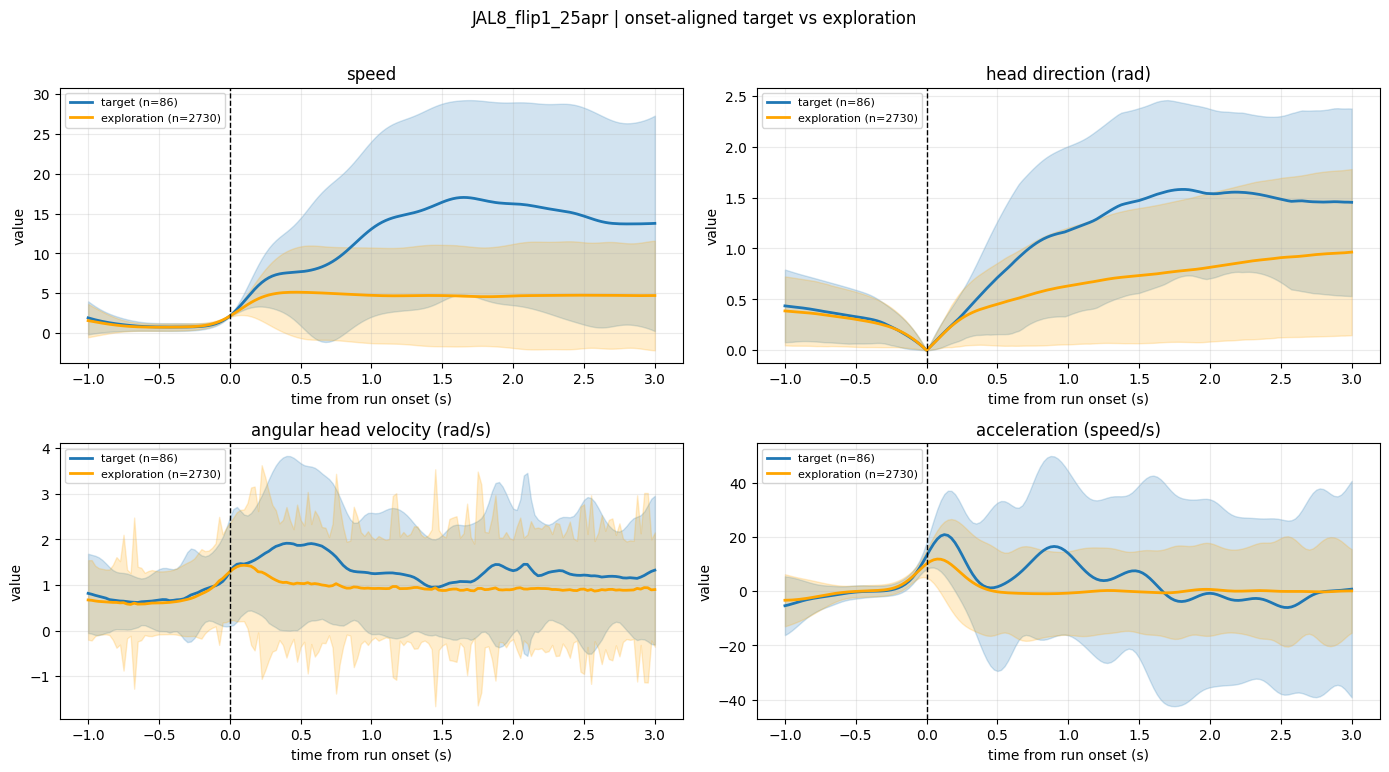

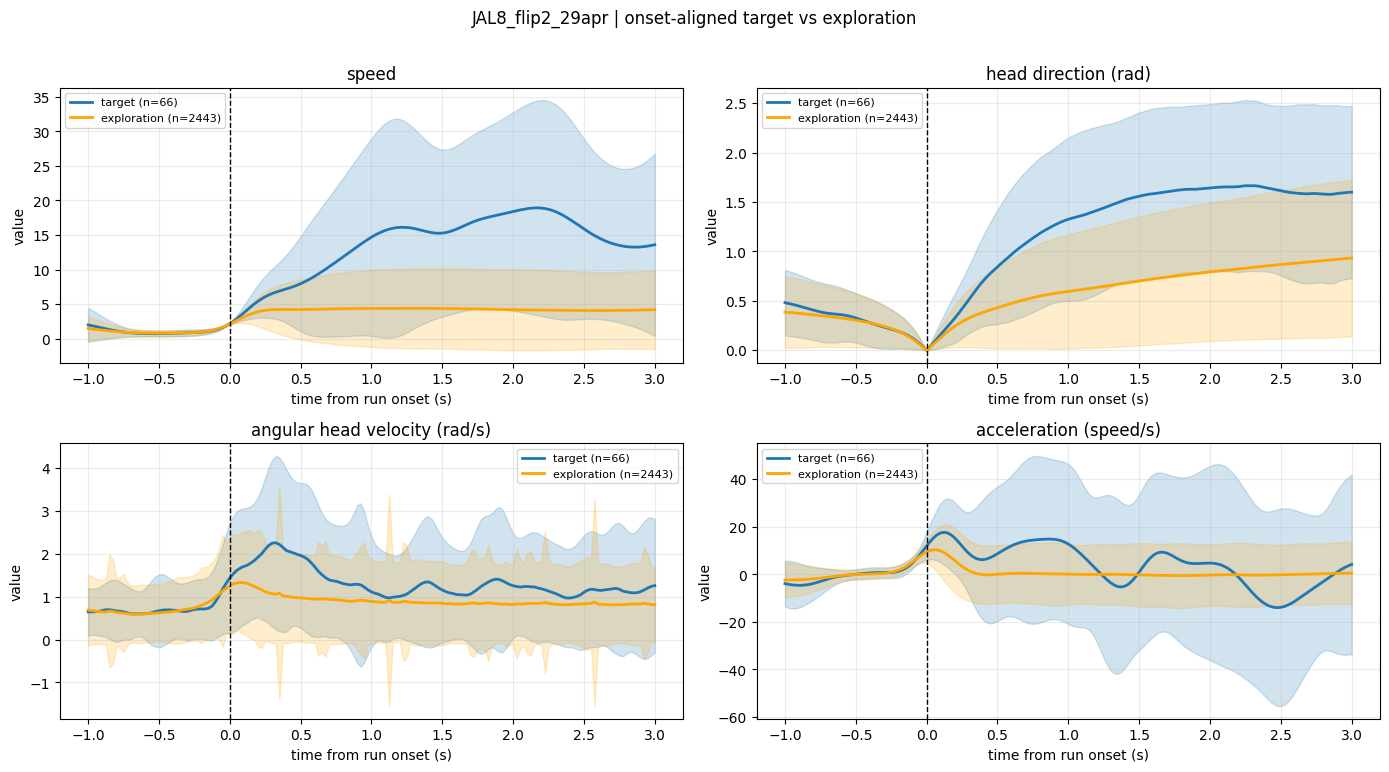

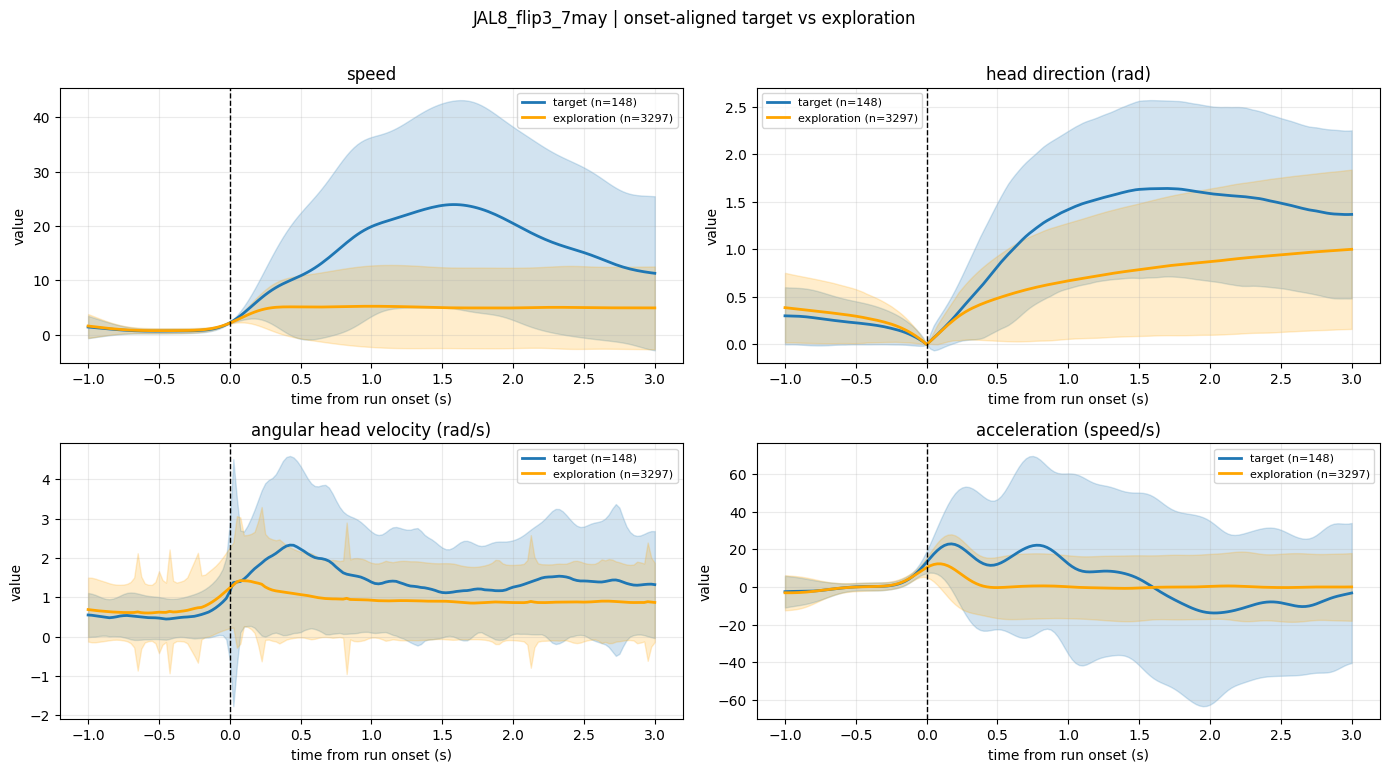

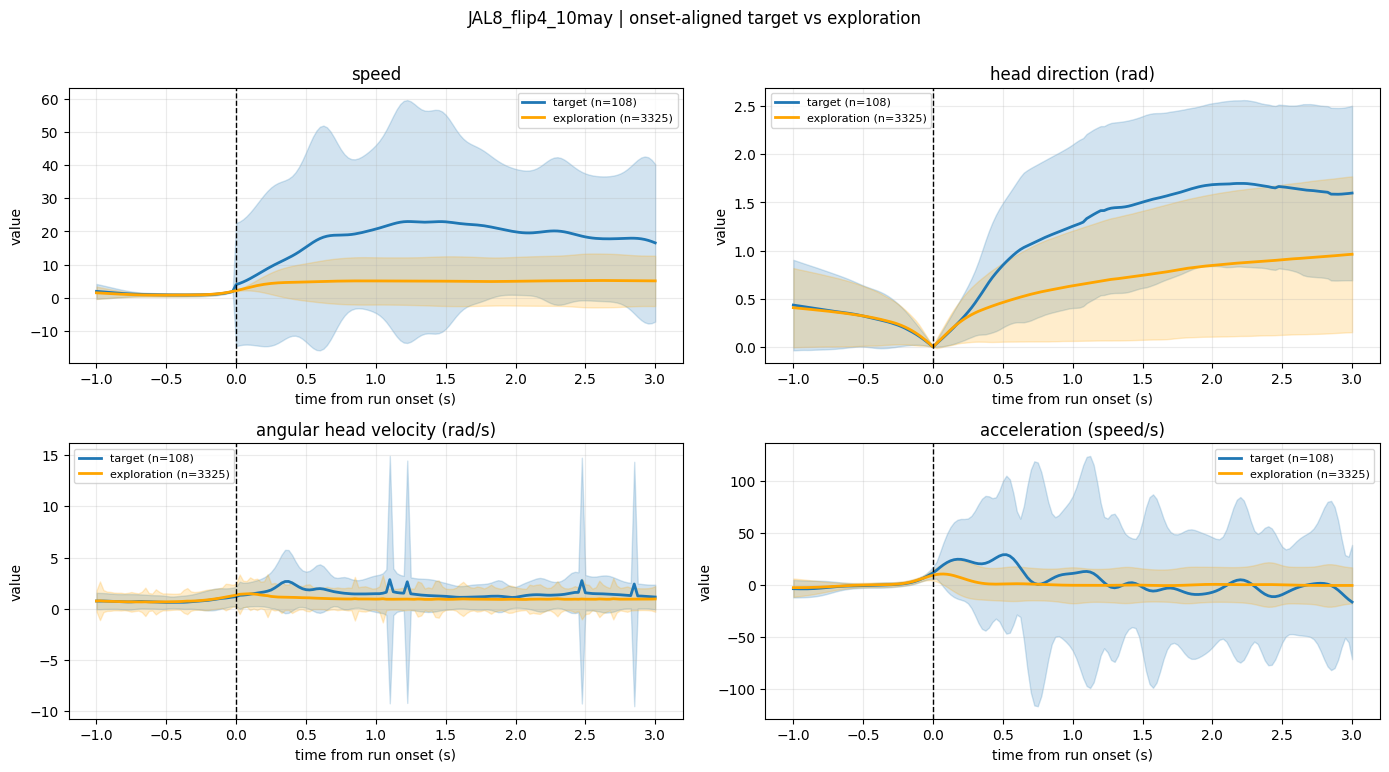

In [35]:
analyzer.plot_run_aligned_dynamics_per_session(
    features_to_plot=["speed", "hdir", "ang_vel", "accel"],
    pre_s=1.0,
    post_s=3.0,
    target_overlap_threshold=0.0,
    with_std=True,
    output_prefix="run_aligned_lines",
)
plt.show()

In [43]:
analyzer.generate_report()

# Display report
report_path = analyzer.output_dir / 'phase1_analysis_report.txt'
print("\n" + "="*80)
print("PHASE 1 REPORT")
print("="*80)
with open(report_path) as f:
    print(f.read())

2026-06-12 19:19:34.640 | INFO     | behave_analysis.analyze.analyze_homing_signature:generate_report:611 - Generating Phase 1 report...
2026-06-12 19:19:34.646 | INFO     | behave_analysis.analyze.analyze_homing_signature:generate_report:655 - Report saved to behave_analysis\analyze\homing_analysis_results\phase1_analysis_report.txt



PHASE 1 REPORT
PHASE 1: HOMING DETECTION ANALYSIS - RUN HYPOTHESIS & FEATURE EXTRACTION

RUN HYPOTHESIS VALIDATION
--------------------------------------------------------------------------------
Hypothesis Status: ✗ FAILED
  Requirement: >95% of target frames within extracted runs

  JAL4_3rdSept:
    - Target in runs: 97.0%
    - Target events: 75
    - Runs extracted: 2762
  JAL4_19thSept:
    - Target in runs: 97.1%
    - Target events: 94
    - Runs extracted: 3081
  JAL4_11thSept:
    - Target in runs: 96.7%
    - Target events: 50
    - Runs extracted: 2822
  JAL5_8thSept:
    - Target in runs: 97.4%
    - Target events: 79
    - Runs extracted: 1967
  JAL5_21stSept:
    - Target in runs: 98.1%
    - Target events: 58
    - Runs extracted: 2157
  JAL6_28mar:
    - Target in runs: 98.4%
    - Target events: 166
    - Runs extracted: 3178
  JAL6_flip4_21mar:
    - Target in runs: 97.7%
    - Target events: 160
    - Runs extracted: 2996
  JAL6_flip3_18mar:
    - Target in runs: 9

In [83]:
# Phase 2: classify runs using top 4 features (excluding displacement_vertical_ratio)
# all_run_features = analyzer.extract_features_for_all_runs()
discrimination_results = analyzer.compute_feature_distributions()

phase2_candidates = analyzer.run_phase2_classification(
    top_n_features=4,
    exclude_features=["displacement_vertical_ratio"],
    target_recall=0.90,
    max_run_duration_s=None,  # auto uses target run-duration quantile
    auto_duration_cap_quantile=0.95,
 )

print("\nSelected features for Phase 2:", analyzer.phase2_selected_features)
if hasattr(analyzer, "phase2_duration_cap_s") and analyzer.phase2_duration_cap_s is not None:
    print(f"Run duration cap: <= {analyzer.phase2_duration_cap_s:.3f} s")

print("\nLearned gates:")
for fname in analyzer.phase2_selected_features:
    g = analyzer.phase2_gates[fname]
    print(
        f"  {fname}: keep if value {g['direction']} {g['threshold']:.4f} "
        f"(single-feature recall={g['recall']:.3f}, precision={g['precision']:.3f})"
    )

print("\nCandidate runs per session:")
for s, runs in phase2_candidates.items():
    print(f"  {s}: {len(runs)}")

2026-06-17 12:59:12.994 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:401 - Computing feature distributions and discrimination power...
2026-06-17 12:59:13.064 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:406 -   Target runs: 2370
2026-06-17 12:59:13.066 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:407 -   Exploration runs: 81233
2026-06-17 12:59:13.776 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:473 - Top 10 discriminative features:
2026-06-17 12:59:13.778 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:475 -   1. net_dy: Cohen's d=1.895, AUC=0.930
2026-06-17 12:59:13.780 | INFO     | behave_analysis.analyze.analyze_homing_signature:compute_feature_distributions:475 -   2. net_distance: Cohen's d=1.750, AUC=0.869
2026-06-17 12:59:13.783 | INFO     | behave_


Selected features for Phase 2: ['net_dy', 'net_distance', 'speed_mean', 'speed_peak']
Run duration cap: <= 5.325 s

Learned gates:
  net_dy: keep if value >= 1.3854 (single-feature recall=0.900, precision=0.102)
  net_distance: keep if value >= 3.7957 (single-feature recall=0.902, precision=0.051)
  speed_mean: keep if value >= 6.7581 (single-feature recall=0.900, precision=0.052)
  speed_peak: keep if value >= 8.7759 (single-feature recall=0.901, precision=0.051)

Candidate runs per session:
  JAL4_3rdSept: 786
  JAL4_19thSept: 836
  JAL4_11thSept: 515
  JAL5_8thSept: 592
  JAL5_21stSept: 452
  JAL6_28mar: 700
  JAL6_flip4_21mar: 796
  JAL6_flip3_18mar: 835
  JAL6_flip5_25mar: 694
  JAL7_sesh8_9apr: 1291
  JAL7_flip5_22mar: 612
  JAL7_flip2_12mar: 850
  JAL7_sesh9_16apr: 1105
  JAL7_23apr: 1017
  JAL8_flip1_25apr: 852
  JAL8_flip2_29apr: 608
  JAL8_flip3_7may: 959
  JAL8_flip4_10may: 926



Phase 3 overlap summary (manual>=0.5, candidate>=0.5):
  JAL4_3rdSept: manual=75 | candidates=786 | recall=0.760 | precision=0.107 | strict=0.070
  JAL4_19thSept: manual=94 | candidates=836 | recall=0.830 | precision=0.135 | strict=0.089
  JAL4_11thSept: manual=50 | candidates=515 | recall=0.820 | precision=0.118 | strict=0.076
  JAL5_8thSept: manual=79 | candidates=592 | recall=0.709 | precision=0.182 | strict=0.090
  JAL5_21stSept: manual=58 | candidates=452 | recall=0.776 | precision=0.137 | strict=0.091
  JAL6_28mar: manual=166 | candidates=700 | recall=0.904 | precision=0.233 | strict=0.209
  JAL6_flip4_21mar: manual=160 | candidates=796 | recall=0.800 | precision=0.183 | strict=0.151
  JAL6_flip3_18mar: manual=193 | candidates=835 | recall=0.865 | precision=0.234 | strict=0.198
  JAL6_flip5_25mar: manual=139 | candidates=694 | recall=0.820 | precision=0.220 | strict=0.163
  JAL7_sesh8_9apr: manual=56 | candidates=1291 | recall=0.946 | precision=0.043 | strict=0.041
  JAL7_flip5_

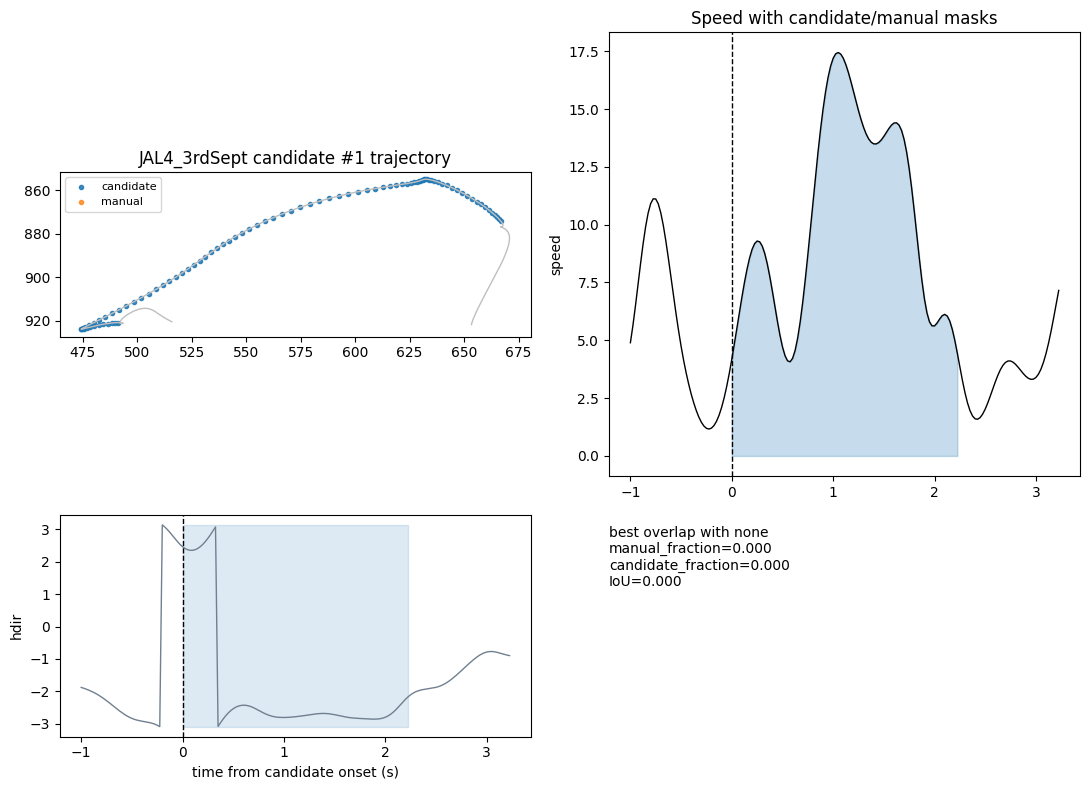

In [84]:
# Phase 3: fractional overlap with manual labels + visualizer
phase3 = analyzer.compute_phase3_fractional_overlap(
    candidates_by_session=phase2_candidates,
    manual_fraction_threshold=0.50,
    candidate_fraction_threshold=0.50,
 )

summary = phase3['summary']
print("\nPhase 3 overlap summary (manual>=0.5, candidate>=0.5):")
for s, stats_dict in summary.items():
    print(
        f"  {s}: manual={stats_dict['num_manual']} | candidates={stats_dict['num_candidates']} "
        f"| recall={stats_dict['manual_recall_at_threshold']:.3f} "
        f"| precision={stats_dict['candidate_precision_at_threshold']:.3f} "
        f"| strict={stats_dict['strict_pair_precision']:.3f}"
    )

# Visualize one candidate run against best-matching manual event (by IoU)
session_for_view = list(phase2_candidates.keys())[0]
if len(phase2_candidates[session_for_view]) > 0:
    analyzer.plot_phase3_event_view(session_name=session_for_view, candidate_idx=1, pad_s=1.0)
    plt.show()
else:
    print(f"No candidate runs available to visualize in {session_for_view}")

Events analyzed: 1760
Thresholds: thr1=1.00 cm/s, thr2=2.00 cm/s

Min speed summaries:
min_speed_full: n=1760 | p25=1.310, p50=2.370, p75=4.306, p90=8.705, p95=9.554
min_speed_core_excl_0p5s: n=1747 | p25=3.790, p50=8.424, p75=14.816, p90=26.713, p95=36.836

Below-threshold duration summaries (s):
below_1.0_full: n=357 | p25=0.075, p50=0.150, p75=0.325, p90=0.610, p95=0.855
below_1.0_core: n=132 | p25=0.144, p50=0.300, p75=0.581, p90=0.973, p95=1.309
below_2.0_full: n=970 | p25=0.075, p50=0.175, p75=0.275, p90=0.550, p95=0.875
below_2.0_core: n=288 | p25=0.125, p50=0.250, p75=0.556, p90=1.033, p95=1.482


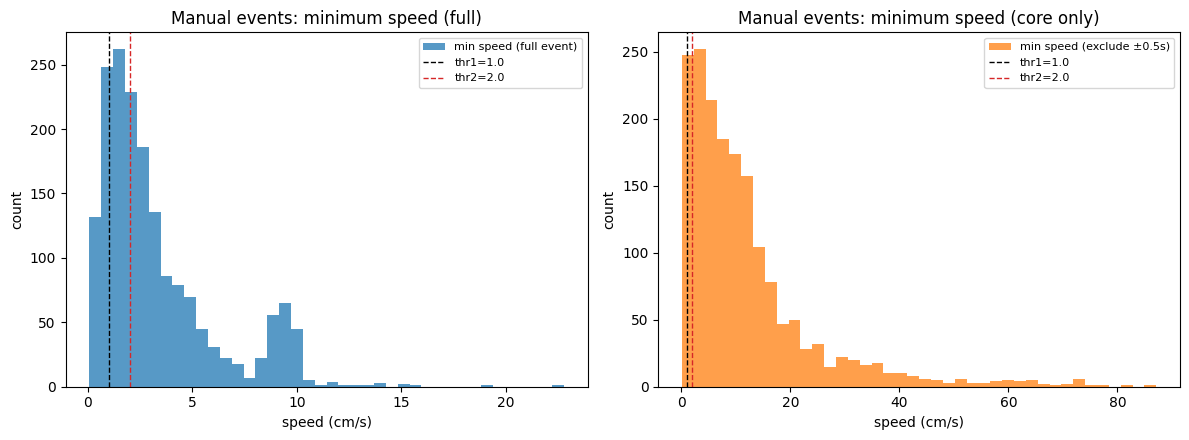

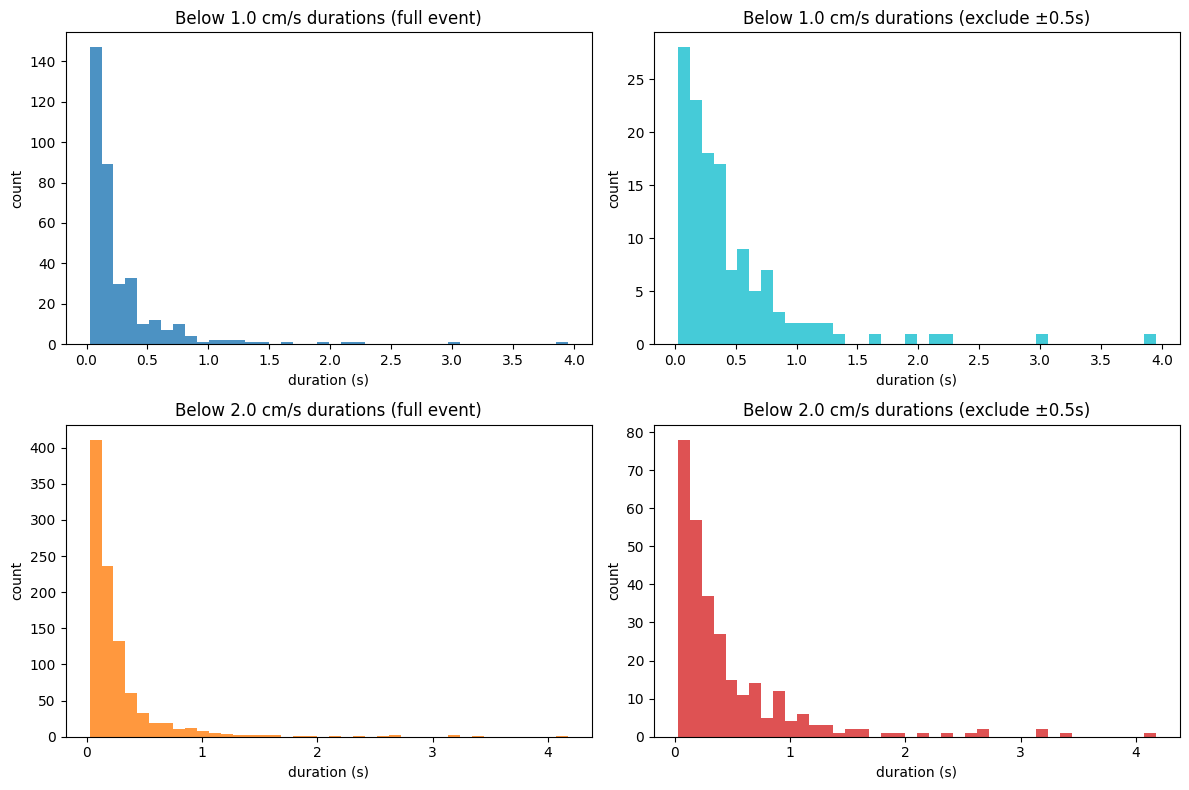

In [48]:
# Phase 1 empirical speed analysis for manual target events (homings + escapes)
import pandas as pd
from settings.settings_analyze_behave import settings_analyze_behave

def _contiguous_lengths(mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0 or not np.any(mask):
        return np.array([], dtype=int)
    padded = np.concatenate([[False], mask, [False]])
    d = np.diff(padded.astype(int))
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0] - 1
    return (ends - starts + 1).astype(int)

def _event_ranges_from_mask(mask):
    mask = np.asarray(mask, dtype=bool)
    padded = np.concatenate([[False], mask, [False]])
    d = np.diff(padded.astype(int))
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0] - 1
    return list(zip(starts.tolist(), ends.tolist()))

thr1 = float(settings_analyze_behave.homing_run_sustained_speed_threshold)  # expected ~1 cm/s
thr2 = 2.0

rows = []
all_min_full = []
all_min_core = []
all_low_1_full = []
all_low_1_core = []
all_low_2_full = []
all_low_2_core = []

for s_name, data in analyzer.session_data.items():
    video_df = data['video_df']
    fps = float(data['fps'])
    trim = int(round(0.5 * fps))
    speed = video_df['speed'].to_numpy()
    is_target = data['frame_labels']['is_target']
    events = _event_ranges_from_mask(is_target)

    for ev_i, (on, off) in enumerate(events):
        seg = speed[on:off + 1]
        if len(seg) == 0:
            continue

        min_full = float(np.nanmin(seg))
        if len(seg) > 2 * trim:
            seg_core = seg[trim:-trim]
            min_core = float(np.nanmin(seg_core))
        else:
            seg_core = np.array([], dtype=float)
            min_core = np.nan

        all_min_full.append(min_full)
        if np.isfinite(min_core):
            all_min_core.append(min_core)

        low1_full = _contiguous_lengths(seg < thr1) / fps
        low2_full = _contiguous_lengths(seg < thr2) / fps
        all_low_1_full.extend(low1_full.tolist())
        all_low_2_full.extend(low2_full.tolist())

        if len(seg_core) > 0:
            low1_core = _contiguous_lengths(seg_core < thr1) / fps
            low2_core = _contiguous_lengths(seg_core < thr2) / fps
        else:
            low1_core = np.array([], dtype=float)
            low2_core = np.array([], dtype=float)

        all_low_1_core.extend(low1_core.tolist())
        all_low_2_core.extend(low2_core.tolist())

        rows.append({
            'session_name': s_name,
            'event_idx': ev_i,
            'onset': on,
            'offset': off,
            'duration_s': (off - on + 1) / fps,
            'min_speed_full': min_full,
            'min_speed_core_excl_0p5s': min_core,
            'n_low1_full': int(len(low1_full)),
            'n_low1_core': int(len(low1_core)),
            'n_low2_full': int(len(low2_full)),
            'n_low2_core': int(len(low2_core)),
        })

manual_speed_df = pd.DataFrame(rows)
print(f"Events analyzed: {len(manual_speed_df)}")
print(f"Thresholds: thr1={thr1:.2f} cm/s, thr2={thr2:.2f} cm/s")

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].hist(all_min_full, bins=40, alpha=0.75, color='tab:blue', label='min speed (full event)')
axs[0].axvline(thr1, color='k', ls='--', lw=1, label=f'thr1={thr1:.1f}')
axs[0].axvline(thr2, color='tab:red', ls='--', lw=1, label=f'thr2={thr2:.1f}')
axs[0].set_title('Manual events: minimum speed (full)')
axs[0].set_xlabel('speed (cm/s)')
axs[0].set_ylabel('count')
axs[0].legend(fontsize=8)

axs[1].hist(all_min_core, bins=40, alpha=0.75, color='tab:orange', label='min speed (exclude ±0.5s)')
axs[1].axvline(thr1, color='k', ls='--', lw=1, label=f'thr1={thr1:.1f}')
axs[1].axvline(thr2, color='tab:red', ls='--', lw=1, label=f'thr2={thr2:.1f}')
axs[1].set_title('Manual events: minimum speed (core only)')
axs[1].set_xlabel('speed (cm/s)')
axs[1].set_ylabel('count')
axs[1].legend(fontsize=8)
plt.tight_layout()

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].hist(all_low_1_full, bins=40, alpha=0.8, color='tab:blue')
axs[0, 0].set_title(f'Below {thr1:.1f} cm/s durations (full event)')
axs[0, 0].set_xlabel('duration (s)')
axs[0, 0].set_ylabel('count')

axs[0, 1].hist(all_low_1_core, bins=40, alpha=0.8, color='tab:cyan')
axs[0, 1].set_title(f'Below {thr1:.1f} cm/s durations (exclude ±0.5s)')
axs[0, 1].set_xlabel('duration (s)')
axs[0, 1].set_ylabel('count')

axs[1, 0].hist(all_low_2_full, bins=40, alpha=0.8, color='tab:orange')
axs[1, 0].set_title(f'Below {thr2:.1f} cm/s durations (full event)')
axs[1, 0].set_xlabel('duration (s)')
axs[1, 0].set_ylabel('count')

axs[1, 1].hist(all_low_2_core, bins=40, alpha=0.8, color='tab:red')
axs[1, 1].set_title(f'Below {thr2:.1f} cm/s durations (exclude ±0.5s)')
axs[1, 1].set_xlabel('duration (s)')
axs[1, 1].set_ylabel('count')
plt.tight_layout()

def _summary(x, name):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        print(f"{name}: no samples")
        return
    q = np.nanpercentile(x, [25, 50, 75, 90, 95])
    print(f"{name}: n={len(x)} | p25={q[0]:.3f}, p50={q[1]:.3f}, p75={q[2]:.3f}, p90={q[3]:.3f}, p95={q[4]:.3f}")

print('\nMin speed summaries:')
_summary(all_min_full, 'min_speed_full')
_summary(all_min_core, 'min_speed_core_excl_0p5s')

print('\nBelow-threshold duration summaries (s):')
_summary(all_low_1_full, f'below_{thr1:.1f}_full')
_summary(all_low_1_core, f'below_{thr1:.1f}_core')
_summary(all_low_2_full, f'below_{thr2:.1f}_full')
_summary(all_low_2_core, f'below_{thr2:.1f}_core')

In [85]:
# Syd viewer for Phase 2 candidates vs manual labels (session-level, like Homing_Quality_new_logic)
from syd import make_viewer
from behave_analysis.utils.arena_plotting import Arena

def _events_from_mask(mask):
    padded = np.concatenate([[False], np.asarray(mask, dtype=bool), [False]])
    d = np.diff(padded.astype(int))
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0] - 1
    return starts, ends

viewer = make_viewer()
viewer.add_integer('trial', min=0, max=500)
viewer.add_integer('speed_thresh', min=0, max=20, value=2)
viewer.add_integer('session_idx', min=0, max=len(analyzer.session_data) - 1, value=0)

def plot(state):
    idx = int(state['trial'])
    # get session data
    s_view = list(experiments_objects.keys())[int(state['session_idx'])]
    data = analyzer.session_data[s_view]
    tracking = data['tracking_data']
    video_df = data['video_df']
    n_frames = len(video_df)
    cand_on = np.array([on for on, _ in phase2_candidates[s_view]], dtype=int)
    cand_off = np.array([off for _, off in phase2_candidates[s_view]], dtype=int)
    man_on, man_off = _events_from_mask(data['frame_labels']['is_target'])

    candidate_mask = np.zeros(n_frames, dtype=bool)
    for on, off in zip(cand_on, cand_off):
        candidate_mask[on:off + 1] = True

    manual_mask = np.asarray(data['frame_labels']['is_target'], dtype=bool)

    all_onsets = np.concatenate([cand_on, man_on]) if len(man_on) > 0 else cand_on.copy()
    all_offsets = np.concatenate([cand_off, man_off]) if len(man_off) > 0 else cand_off.copy()
    all_source = np.concatenate([np.zeros(len(cand_on), dtype=int), np.ones(len(man_on), dtype=int)]) if len(man_on) > 0 else np.zeros(len(cand_on), dtype=int)

    order = np.argsort(all_onsets)
    all_onsets = all_onsets[order]
    all_offsets = all_offsets[order]
    all_source = all_source[order]

    # get onset of interest
    if idx > len(all_onsets) - 1:
        print(f"Trial index {idx} exceeds number of events ({len(all_onsets)}) in session {s_view}.")
        return
    onset = int(all_onsets[idx])
    offset = int(all_offsets[idx])
    # determine condition
    if video_df['barrier_present'].to_numpy()[all_onsets[idx]] == False:
        condition = 'shelter_only'
    elif video_df['barrier_present'].to_numpy()[all_onsets[idx]] == True:
        condition = 'barrier_pre_flip'
        if video_df['barrier_flipped'].to_numpy()[all_onsets[idx]] == True:
            condition = 'barrier_post_flip'
    pad = int(round(fps))
    start = max(0, onset - pad)
    stop = min(n_frames, offset + pad + 1)

    t = (np.arange(start, stop) - start) / fps
    x = tracking['avg_loc'][start:stop, 0]
    y = tracking['avg_loc'][start:stop, 1]
    speed = video_df['speed'][start:stop].to_numpy()
    hdir = video_df['hdir'][start:stop].to_numpy()

    cand_win = candidate_mask[start:stop]
    man_win = manual_mask[start:stop]

    fig, axs = plt.subplots(3, 2, figsize=(10, 11), gridspec_kw={'height_ratios': [2, 1, 1]})

    axs[0, 0].plot(x, y, color='0.75', lw=1)
    axs[0, 0].scatter(x[cand_win], y[cand_win], s=8, color='tab:blue', alpha=0.8, label='candidate')
    axs[0, 0].scatter(x[0], y[0], s=35, color='green', label='window start')
    axs[0, 0].scatter(x[-1], y[-1], s=35, color='red', label='window end')
    Arena(ax = axs[0, 0], condition = condition,
                barrier_coordinates = tracking['barrier_loc'][:-1], full_image = False)

    axs[0, 1].scatter(x[man_win], y[man_win], s=8, color='tab:orange', alpha=0.8, label='manual')
    axs[0, 1].plot(x, y, color='0.85', lw=1)
    Arena(ax = axs[0, 1], condition = condition,
                barrier_coordinates = tracking['barrier_loc'][:-1], full_image = False)

    src = 'candidate' if all_source[idx] == 0 else 'manual'
    axs[0, 0].set_title(f'{s_view} | trial {idx} ({src}) | onset={onset} offset={offset}')
    axs[0, 0].set_xlim(0, 1024)
    axs[0, 0].set_ylim(0, 1024)
    axs[0, 0].set_aspect('equal')
    axs[0, 0].invert_yaxis()
    axs[0, 0].legend(loc='upper right', fontsize=8)

    axs[0, 1].set_xlim(0, 1024)
    axs[0, 1].set_ylim(0, 1024)
    axs[0, 1].set_aspect('equal')
    axs[0, 1].invert_yaxis()

    axs[1, 0].plot(t, speed, color='black', lw=1)
    axs[1, 0].fill_between(t, 0, speed, where=cand_win, color='tab:blue', alpha=0.25)
    ax = axs[1,0].twinx()
    ax.plot(t, speed > state['speed_thresh'], color='tab:red', lw=1, label='speed>2cm/s')
    axs[1, 1].plot(t, speed, color='black', lw=1)
    axs[1, 1].fill_between(t, 0, speed, where=man_win, color='tab:orange', alpha=0.18)
    ax = axs[1,1].twinx()
    ax.plot(t, speed > state['speed_thresh'], color='tab:red', lw=1, label='speed>2cm/s')
    axs[1, 0].axvline((onset - start) / fps, color='tab:green', ls='--', lw=1)
    axs[1, 0].axvline((offset - start) / fps, color='tab:red', ls='--', lw=1)
    axs[1, 0].set_ylabel('speed')

    axs[2, 0].plot(t, hdir, color='slategray', lw=1)
    axs[2, 0].fill_between(t, np.nanmin(hdir), np.nanmax(hdir), where=cand_win, color='tab:blue', alpha=0.12)
    axs[2, 1].plot(t, hdir, color='slategray', lw=1)
    axs[2, 1].fill_between(t, np.nanmin(hdir), np.nanmax(hdir), where=man_win, color='tab:orange', alpha=0.10)
    axs[2, 0].axvline((onset - start) / fps, color='tab:green', ls='--', lw=1)
    axs[2, 0].axvline((offset - start) / fps, color='tab:red', ls='--', lw=1)
    axs[2, 0].set_ylabel('hdir')
    axs[2, 0].set_xlabel('time (s)')

    overlap = int(np.sum(candidate_mask[onset:offset + 1] & manual_mask[onset:offset + 1]))
    manual_count = int(np.sum(manual_mask[onset:offset + 1]))
    cand_count = int(np.sum(candidate_mask[onset:offset + 1]))
    axs[0, 1].set_title(f'candidate frames={cand_count} | manual frames={manual_count} | overlap={overlap}')

    plt.tight_layout()
    return fig

viewer.set_plot(plot)
viewer.show()